In [30]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

# Define the data structure
class PortFolio(TypedDict):
    amount_usd: float
    total_usd: float
    target_curr : Literal['INR', 'EUR']
    total: float

In [31]:
# Define node functions
def cal_total(state: PortFolio) -> PortFolio:
    state['total_usd'] = float(state['amount_usd'] * 1.08)
    return state

def cal_inr(state: PortFolio) -> PortFolio:
    state['total'] = float(state['total_usd'] * 85)
    return state
def cal_eur(state: PortFolio) -> PortFolio:
    state['total'] = float(state['total_usd'] * 8)
    return state
def choose_conversion(state: PortFolio) -> str:
    return state['target_curr']

In [32]:

# Build the graph
builder = StateGraph(PortFolio)
builder.add_node("calculate_total_node", cal_total)
builder.add_node("calculate_inr_node", cal_inr)
builder.add_node("calculate_eur_node", cal_eur)
builder.add_edge(START, "calculate_total_node")
builder.add_conditional_edges("calculate_total_node",choose_conversion,
                              {
                                  "INR":"calculate_inr_node",
                                  "EUR":"calculate_eur_node"
                              })
builder.add_edge(["calculate_inr_node", "calculate_eur_node"],END)

# Compile the graph
graph = builder.compile()

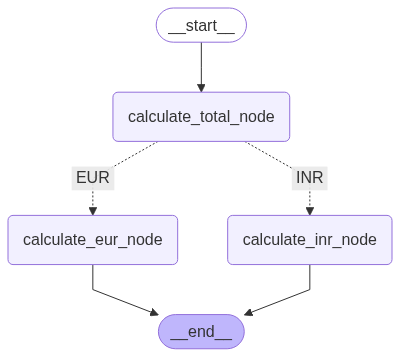

In [33]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
result = graph.invoke({
    "amount_usd": 1000.0,
    "target_curr": 'EUR'
})

print(result)


{'amount_usd': 1000.0, 'total_usd': 1080.0, 'target_curr': 'EUR', 'total': 8640.0}
